In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import ellipk

In [3]:
# functions for the 1D Ising model

def create_chain(N):
    """
    Create a random chain of spins (-1 or +1) of length N.
    """
    chain = np.random.randint(0,2, N)
    chain = np.where(chain == 0, -1, 1)
    return chain    

def chain_energy_1D(chain, J, h=0.0):
    """
    Calculate the total energy of te chain using the 1D Ising Hamiltonian:
    H = -J * sum(s_i * s_{i+1}) - h * sum(s_i)
    """
    
    interaction = -J * np.sum(chain[:-1] * chain[1:]) # the spin-spin interaction term
    field       = -h * np.sum(chain) # the external field term
    return interaction + field

def compute_delta_E(chain, i, J, h=0.0):
    """
    Local energy change from flipping spin i. (using periodic boundary conditions)
    """
    N = len(chain)
    left  = chain[(i - 1) % N]
    right = chain[(i + 1) % N]
    return 2 * J * chain[i] * (left + right) + 2 * h * chain[i] # calculates the energy change from flipping spin i

def energy_acceptance_probability(delta_E, T):
    """
    Calculating the probability of accepting a spin flip according to the Metropolis criterion.
    
    P = 1                    if delta_E <= 0  (always accept)
    P = exp(-delta_E / T)    if delta_E > 0   (accept with Boltzmann probability)
    """
    if delta_E <= 0: # if the energzy change is negative or zero, we always accept the flip
        return 1.0
    else:
        return np.exp(-delta_E / T) # calculates the acceptance probability for a spin flip that increases energy by delta_E at temperature T


def mc_step(chain, J, h, T):
    """
    Attempt one random spin flip using the Metropolis criterion, if the flip is accepted it
    modifies chain in place.
    """
    i       = np.random.randint(len(chain))   # pick a random spin
    delta_E = compute_delta_E(chain, i, J, h) 
    prob    = energy_acceptance_probability(delta_E, T)

    if np.random.random() < prob: # since np.random.random() generates a random float in the range (0.0, 1.0), it will result that we acceot the flip with the % probability that was introduced by the prob function
        chain[i] *= -1                         # flip the spin


def mc_sweep(chain, J, h, T):
    """
    One full sweep: N attempted spin flips.
    """
    for _ in range(len(chain)):
        mc_step(chain, J, h, T)

## The Simulation

In [4]:
def run_simulation(N, J, h, T, n_equilibrate=1000, n_measure=5000):
    """
    Full Ising simulation at a single temperature of T.
    
    Returns the energies per spin and magnetizations per spin recorded during the measurement phase.
    """
    chain = create_chain(N)

    # reaching the equilibrium
    for _ in range(n_equilibrate):
        mc_sweep(chain, J, h, T)

    # measuring and recording observables since we would like to calculate expected values of energy and magnetization at the given temperature T
    energies       = []
    magnetizations = []

    for _ in range(n_measure):
        mc_sweep(chain, J, h, T)
        energies.append(chain_energy_1D(chain, J, h) / N)   # per spin
        magnetizations.append(np.sum(chain) / N)             # per spin

    return np.array(energies), np.array(magnetizations)

In [6]:
J = 1.0
h = 0.0
T = 2.0 # temperature in units of J/k_B (k_B=1). We have chosen T=2.0 which is above the critical temperature of the 1D Ising model (T_c = 0), so we expect to see a disordered phase with low magnetization and high energy fluctuations. On the other hand it is not too high, for the chain to be completely random.
N = 100

energies, magnetizations = run_simulation(N, J, h, T,n_equilibrate=100,n_measure=100)

print(f"energy per spin = {energies.mean():.4f}")
print(f"magnetization per spin = {np.abs(magnetizations).mean():.4f}")
print(f"Specific heat = {(1/T**2) * N * energies.var():.4f}")
print(f"Susceptibility = {(1/T)    * N * (magnetizations**2).mean():.4f}")

energy per spin = -0.4448
magnetization per spin = 0.1200
Specific heat = 0.1701
Susceptibility = 1.2048


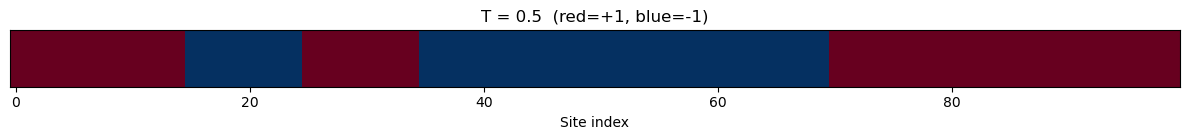

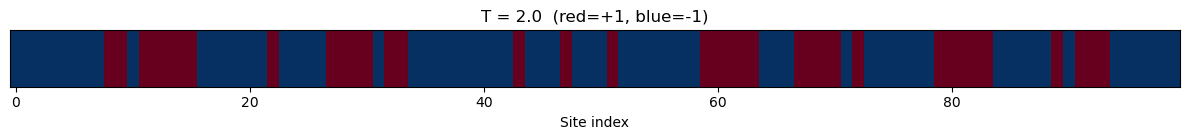

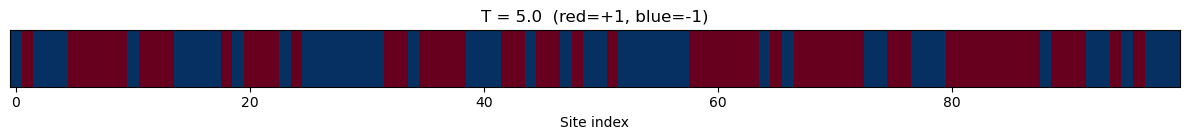

In [5]:
def plot_spin_chain(chain, title="Spin Configuration"):
    fig, ax = plt.subplots(figsize=(12, 1.5))
    ax.imshow(chain[np.newaxis, :], aspect="auto", cmap="RdBu_r",
              vmin=-1, vmax=1, interpolation="nearest")
    ax.set_yticks([])
    ax.set_xlabel("Site index")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

# i have plotted the spin configuration for different temperatures to visually compare order vs disorder. At low T we expect to see large domains of aligned spins (red or blue), while at high T we expect a more random pattern with small domains.
for T_val in [0.5, 2.0, 5.0]:
    chain = create_chain(100)
    for _ in range(2000):
        mc_sweep(chain, J=1.0, h=0.0, T=T_val)
    plot_spin_chain(chain, title=f"T = {T_val}  (red=+1, blue=-1)")

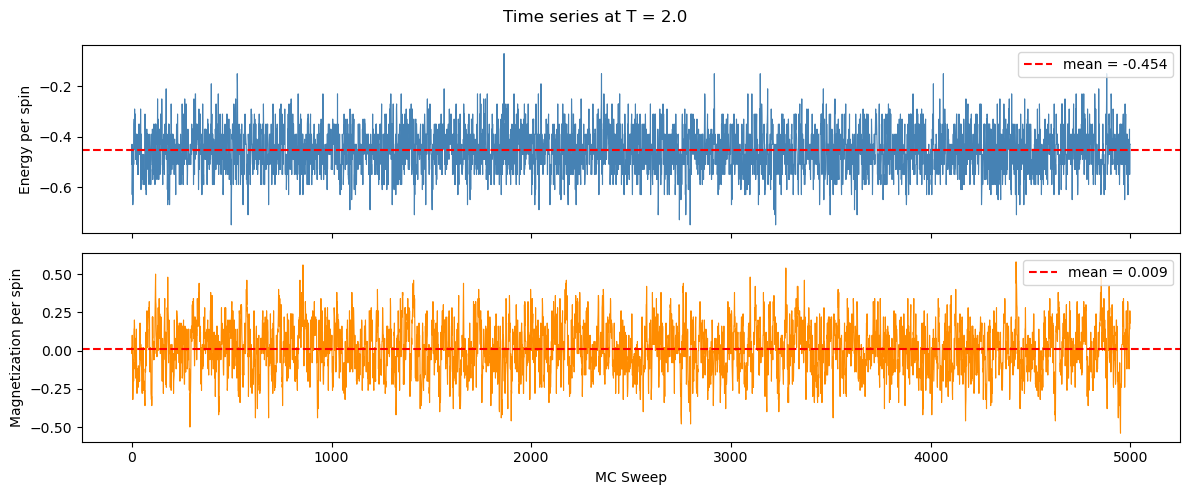

In [ ]:
def plot_timeseries(energies, magnetizations, T):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

    ax1.plot(energies, lw=0.8, color="steelblue")
    ax1.axhline(energies.mean(), color="red", ls="--", label=f"mean = {energies.mean():.3f}")
    ax1.set_ylabel("Energy per spin")
    ax1.legend()

    ax2.plot(magnetizations, lw=0.8, color="darkorange")
    ax2.axhline(magnetizations.mean(), color="red", ls="--", label=f"mean = {magnetizations.mean():.3f}")
    ax2.set_ylabel("Magnetization per spin")
    ax2.set_xlabel("MC Sweep")
    ax2.legend()

    fig.suptitle(f"Time series at T = {T}")
    plt.tight_layout()
    plt.show()

energies, magnetizations = run_simulation(100, J=1.0, h=0.0, T=2.0)
plot_timeseries(energies, magnetizations, T=2.0)

# the simulation was run at T = 2.0 and plot the time series of energy and magnetization per spin. We expect to see fluctuations around some mean values, with no long-term trends since we are in equilibrium. The energy should fluctuate around a value characteristic of T=2, and the magnetization should fluctuate around zero (since T=2 is above the critical temperature for the 1D Ising model).

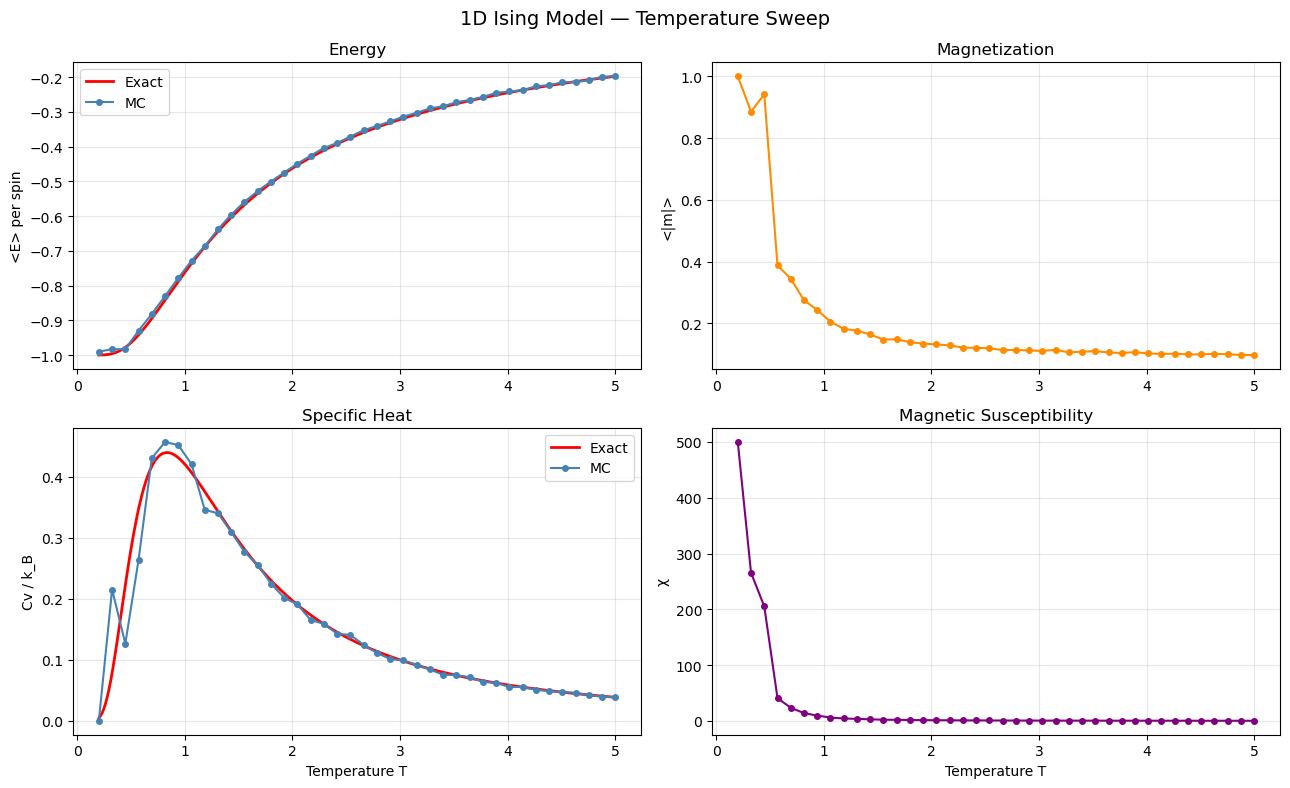

In [7]:
def temperature_sweep(N=100, J=1.0, h=0.0, T_min=0.2, T_max=5.0, n_temps=40):
    temps = np.linspace(T_min, T_max, n_temps)
    E_mean, M_mean, Cv_list, Chi_list = [], [], [], []

    for T in temps:
        print(f"  Running T={T:.2f}...", end="\r")
        energies, mags = run_simulation(N, J, h, T,n_equilibrate=1000,n_measure=3000)
        E_mean.append(energies.mean())
        M_mean.append(np.abs(mags).mean())
        Cv_list.append((1/T**2) * N * energies.var())
        Chi_list.append((1/T)   * N * (mags**2).mean())

    return temps, np.array(E_mean), np.array(M_mean), np.array(Cv_list), np.array(Chi_list)


def plot_temperature_sweep(temps, E, M, Cv, Chi, J=1.0):
    # exact analytical curves
    T_ex  = np.linspace(temps.min(), temps.max(), 300)
    E_ex  = -J * np.tanh(J / T_ex)
    Cv_ex = (J / T_ex)**2 / np.cosh(J / T_ex)**2

    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    fig.suptitle("1D Ising Model — Temperature Sweep", fontsize=14)

    # energy
    ax = axes[0, 0]
    ax.plot(T_ex, E_ex, color="red", lw=2, label="Exact")
    ax.plot(temps, E, "o-", color="steelblue", ms=4, label="MC")
    ax.set_ylabel("<E> per spin")
    ax.set_title("Energy")
    ax.legend()
    ax.grid(alpha=0.3)

    # magnetization
    ax = axes[0, 1]
    ax.plot(temps, M, "o-", color="darkorange", ms=4)
    ax.set_ylabel("<|m|>")
    ax.set_title("Magnetization")
    ax.grid(alpha=0.3)

    # specific heat
    ax = axes[1, 0]
    ax.plot(T_ex, Cv_ex, color="red", lw=2, label="Exact")
    ax.plot(temps, Cv, "o-", color="steelblue", ms=4, label="MC")
    ax.set_ylabel("Cv / k_B")
    ax.set_xlabel("Temperature T")
    ax.set_title("Specific Heat")
    ax.legend()
    ax.grid(alpha=0.3)

    # susceptibility
    ax = axes[1, 1]
    ax.plot(temps, Chi, "o-", color="purple", ms=4)
    ax.set_ylabel("χ")
    ax.set_xlabel("Temperature T")
    ax.set_title("Magnetic Susceptibility")
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


# Run it — takes ~1-2 minutes
temps, E, M, Cv, Chi = temperature_sweep(N=100, J=1.0)
plot_temperature_sweep(temps, E, M, Cv, Chi)

## 2D Ising-model

In [ ]:
def create_lattice(N):
    """
    Create a random 2D lattice of spins of size N x N.
    Each spin is either +1 or -1.
    """
    lattice = np.random.randint(0, 2, (N, N))
    lattice = np.where(lattice == 0, -1, 1)
    return lattice

def lattice_energy_2D(lattice, J, h=0.0):
    """
    Total energy of the 2D Ising lattice.
    Each spin interacts with its 4 neighbours (up, down, left, right).
    Uses periodic boundary conditions.
    """
    # we sum the energy of horizontal bonds (right neighbour)
    horizontal = np.sum(lattice * np.roll(lattice, -1, axis=1))
    # we sum the energy of vertical bonds (down neighbour)
    vertical   = np.sum(lattice * np.roll(lattice, -1, axis=0))

    interaction = -J * (horizontal + vertical)
    field       = -h * np.sum(lattice)
    return interaction + field

def compute_delta_E_2D(lattice, i, j, J, h=0.0):
    """
    Local energy change from flipping spin (i, j). (using a periodic boundary condition)
    
    Since only the 4 neighbours of (i,j) are affected by the flip,
    we can compute delta_E locally without recalculating the full energy:
    
    delta_E = 2 * J * s_{i,j} * (s_{up} + s_{down} + s_{left} + s_{right}) + 2 * h * s_{i,j}
    """
    N = lattice.shape[0]
    
    # we sum the 4 nearest neighbours with periodic boundary conditions
    # % N ensures that edge spins wrap around to the other side of the lattice
    neighbours = (
        lattice[(i - 1) % N, j] +   # up
        lattice[(i + 1) % N, j] +   # down
        lattice[i, (j - 1) % N] +   # left
        lattice[i, (j + 1) % N]     # right
    )
    
    # using the same formula as in the 1D case, just with 4 neighbours instead of 2
    return 2 * J * lattice[i, j] * neighbours + 2 * h * lattice[i, j]


def mc_step_2D(lattice, J, h, T):
    """
    Attempt one random spin flip using the Metropolis criterion.
    Modifies lattice in place.
    
    Randomly selects a spin (i, j) on the lattice, computes the energy
    change delta_E if it were flipped, and accepts or rejects the flip
    based on the Metropolis criterion:
    
        - if delta_E <= 0  -> always flip (lowers energy)
        - if delta_E > 0   -> flip with probability exp(-delta_E / T)
    """
    N = lattice.shape[0]
    
    # it selects a random spin from our NxN lattice.
    i = np.random.randint(N)
    j = np.random.randint(N)
    
    # then computes the energy change if the spin were to be flipped
    delta_E = compute_delta_E_2D(lattice, i, j, J, h)
    
    # it decides whether to flip the spin based on the Metropolis criterion — same as 1D
    if delta_E <= 0 or np.random.random() < np.exp(-delta_E / T):
        lattice[i, j] *= -1   # flip the spin


def mc_sweep_2D(lattice, J, h, T):
    """
    One full sweep: N*N attempted spin flips.
    Modifies lattice in place.
    """
    N = lattice.shape[0]
    
    for _ in range(N * N):
        mc_step_2D(lattice, J, h, T)

In [ ]:
def run_simulation_2D(N, J, h, T, n_equilibrate=1000, n_measure=5000):
    """
    Full 2D Ising simulation at a single temperature T.
    """
    lattice = create_lattice(N)

    # Equilibration — let the lattice forget its random initial state
    for _ in range(n_equilibrate):
        mc_sweep_2D(lattice, J, h, T)

    # Measurement — record observables after every sweep
    energies       = []
    magnetizations = []

    for _ in range(n_measure):
        mc_sweep_2D(lattice, J, h, T)
        energies.append(lattice_energy_2D(lattice, J, h) / N**2)  # per spin
        magnetizations.append(np.sum(lattice) / N**2)              # per spin

    return np.array(energies), np.array(magnetizations)

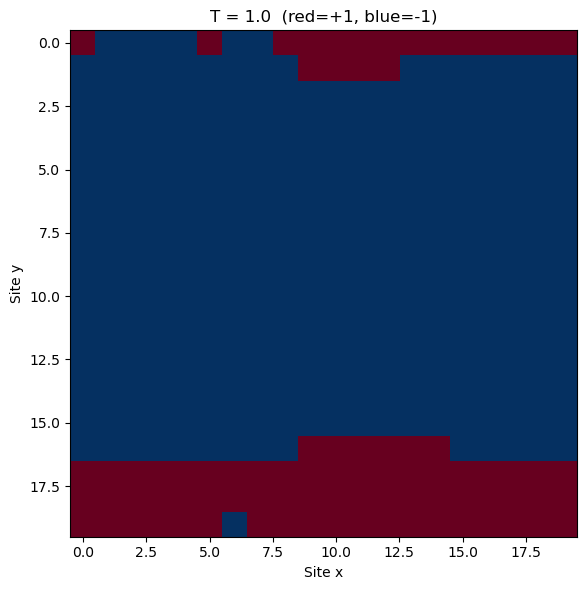

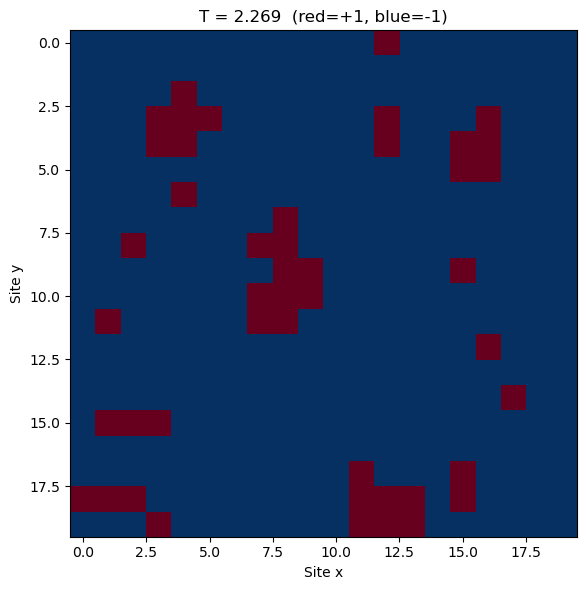

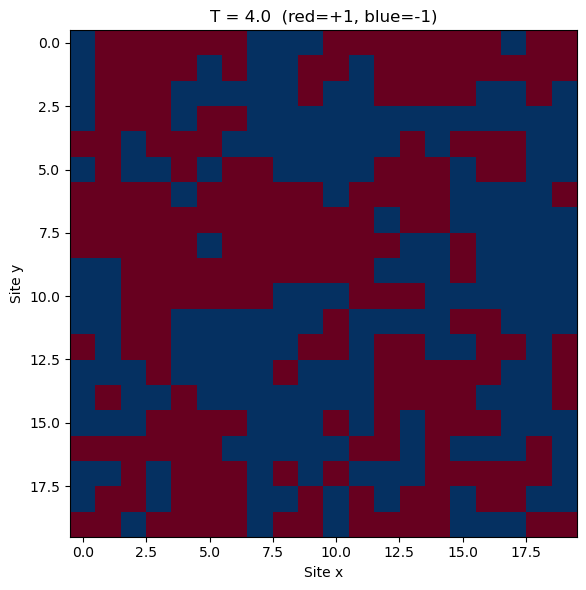

In [4]:
def plot_lattice(lattice, title="Lattice Configuration"):
    """
    Visualise the current spin configuration as a 2D heatmap.
    Red = +1, Blue = -1.
    """
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(lattice, cmap="RdBu_r", vmin=-1, vmax=1, interpolation="nearest")
    ax.set_title(title)
    ax.set_xlabel("Site x")
    ax.set_ylabel("Site y")
    plt.tight_layout()
    plt.show()

# Compare order vs disorder visually
for T_val in [1.0, 2.269, 4.0]:
    lattice = create_lattice(20)
    for _ in range(2000):
        mc_sweep_2D(lattice, J=1.0, h=0.0, T=T_val)
    plot_lattice(lattice, title=f"T = {T_val}  (red=+1, blue=-1)")

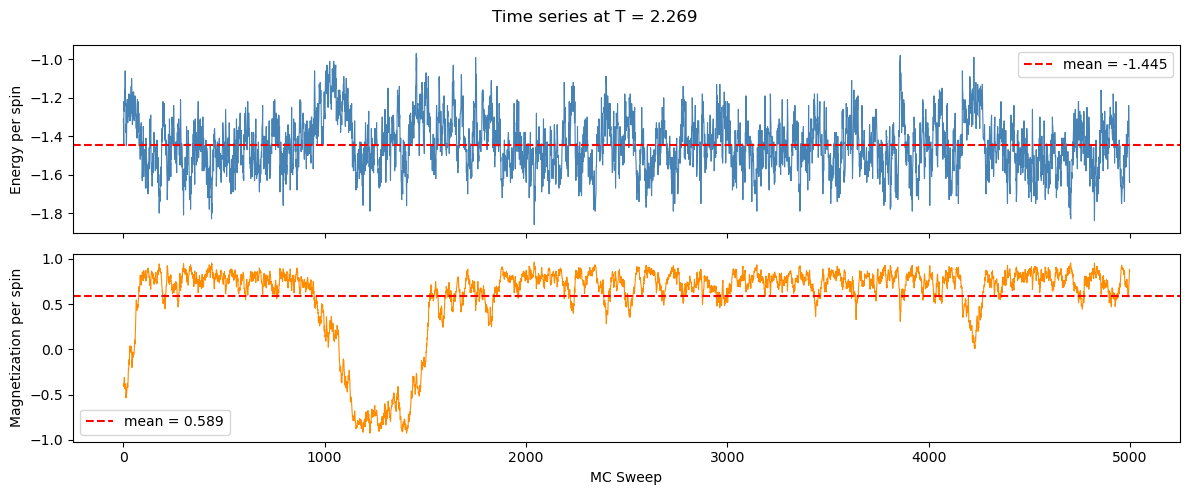

In [11]:
def plot_timeseries_2D(energies, magnetizations, T):
    """
    Plot energy and magnetization per spin over MC sweeps.
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

    ax1.plot(energies, lw=0.8, color="steelblue")
    ax1.axhline(energies.mean(), color="red", ls="--", label=f"mean = {energies.mean():.3f}")
    ax1.set_ylabel("Energy per spin")
    ax1.legend()

    ax2.plot(magnetizations, lw=0.8, color="darkorange")
    ax2.axhline(magnetizations.mean(), color="red", ls="--", label=f"mean = {magnetizations.mean():.3f}")
    ax2.set_ylabel("Magnetization per spin")
    ax2.set_xlabel("MC Sweep")
    ax2.legend()

    fig.suptitle(f"Time series at T = {T}")
    plt.tight_layout()
    plt.show()

energies, magnetizations = run_simulation_2D(N=20, J=1.0, h=0.0, T=2.269)
plot_timeseries_2D(energies, magnetizations, T=2.269)

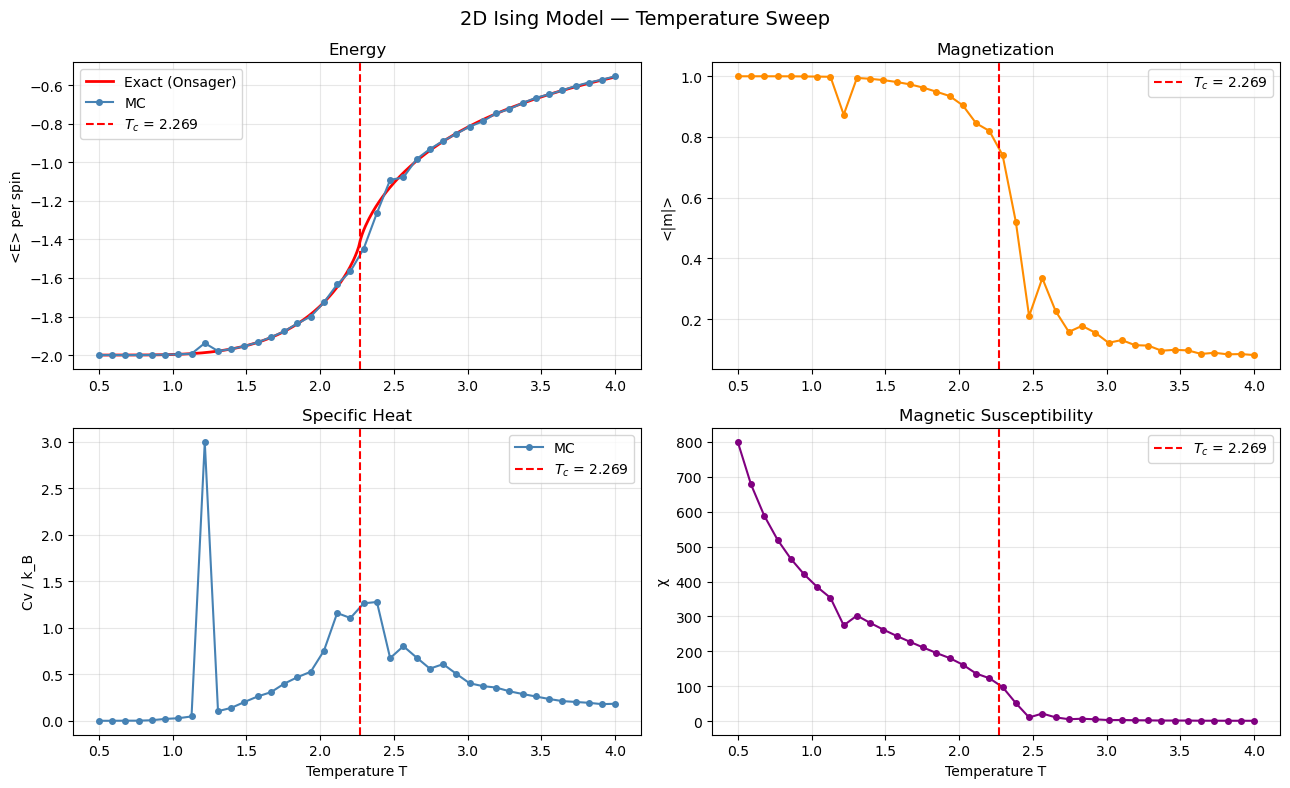

In [ ]:
def temperature_sweep_2D(N=20, J=1.0, h=0.0, T_min=0.5, T_max=4.0, n_temps=40):
    """
    Sweep over temperatures and collect thermodynamic averages.
    """
    temps = np.linspace(T_min, T_max, n_temps)
    E_mean, M_mean, Cv_list, Chi_list = [], [], [], []

    for T in temps:
        print(f"  Running T={T:.2f}...", end="\r")
        energies, mags = run_simulation_2D(N, J, h, T,
                                           n_equilibrate=500,
                                           n_measure=1000)
        E_mean.append(energies.mean())
        M_mean.append(np.abs(mags).mean())
        Cv_list.append((1/T**2) * N**2 * energies.var())
        Chi_list.append((1/T)   * N**2 * (mags**2).mean())

    return temps, np.array(E_mean), np.array(M_mean), np.array(Cv_list), np.array(Chi_list)



def onsager_energy(T, J=1.0):
    """
    Exact Onsager solution for the 2D Ising model energy per spin.
    """
    beta = 1.0 / T
    k    = 2 * np.sinh(2*beta*J) / np.cosh(2*beta*J)**2
    return -J / np.tanh(2*beta*J) * (1 + (2/np.pi) * (2*np.tanh(2*beta*J)**2 - 1) * ellipk(k**2))


def plot_temperature_sweep_2D(temps, E, M, Cv, Chi):
    Tc   = 2.269
    T_ex = np.linspace(temps.min() + 0.01, temps.max(), 300)
    E_ex = [onsager_energy(T) for T in T_ex]

    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    fig.suptitle("2D Ising Model — Temperature Sweep", fontsize=14)

    # Energy with Onsager exact curve
    ax = axes[0, 0]
    ax.plot(T_ex, E_ex, color="red", lw=2, label="Exact (Onsager)")
    ax.plot(temps, E, "o-", color="steelblue", ms=4, label="MC")
    ax.axvline(Tc, color="red", ls="--", label=f"$T_c$ = {Tc}")
    ax.set_ylabel("<E> per spin")
    ax.set_title("Energy")
    ax.legend()
    ax.grid(alpha=0.3)

    # Magnetization
    ax = axes[0, 1]
    ax.plot(temps, M, "o-", color="darkorange", ms=4)
    ax.axvline(Tc, color="red", ls="--", label=f"$T_c$ = {Tc}")
    ax.set_ylabel("<|m|>")
    ax.set_title("Magnetization")
    ax.legend()
    ax.grid(alpha=0.3)

    # Specific heat
    ax = axes[1, 0]
    ax.plot(temps, Cv, "o-", color="steelblue", ms=4, label="MC")
    ax.axvline(Tc, color="red", ls="--", label=f"$T_c$ = {Tc}")
    ax.set_ylabel("Cv / k_B")
    ax.set_xlabel("Temperature T")
    ax.set_title("Specific Heat")
    ax.legend()
    ax.grid(alpha=0.3)

    # Susceptibility
    ax = axes[1, 1]
    ax.plot(temps, Chi, "o-", color="purple", ms=4)
    ax.axvline(Tc, color="red", ls="--", label=f"$T_c$ = {Tc}")
    ax.set_ylabel("χ")
    ax.set_xlabel("Temperature T")
    ax.set_title("Magnetic Susceptibility")
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


temps, E, M, Cv, Chi = temperature_sweep_2D(N=20, J=1.0)
plot_temperature_sweep_2D(temps, E, M, Cv, Chi)